In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline


In [2]:
from sklearn.datasets import load_wine
wine_data=load_wine()


In [3]:
X=wine_data.data
y=wine_data.target

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=15)

In [5]:
pipe=Pipeline (
    [
        ("StandartScaler",StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]
)

In [6]:
#hyperparameter tunning
params={
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__metric': ['euclidean', 'manhattan']
}

In [7]:
grid=GridSearchCV(pipe,param_grid=params,cv=5,scoring="accuracy")

In [8]:
grid.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [9]:
y_pred=grid.predict(X_test)

In [10]:
print(accuracy_score(y_test,y_pred))

1.0


In [11]:
print(confusion_matrix(y_test,y_pred))

[[12  0  0]
 [ 0 12  0]
 [ 0  0 12]]


In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        12

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [13]:
#another data for knn regression


In [14]:
df_reg = pd.read_csv("house_energy_regression.csv")


In [15]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [16]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [17]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


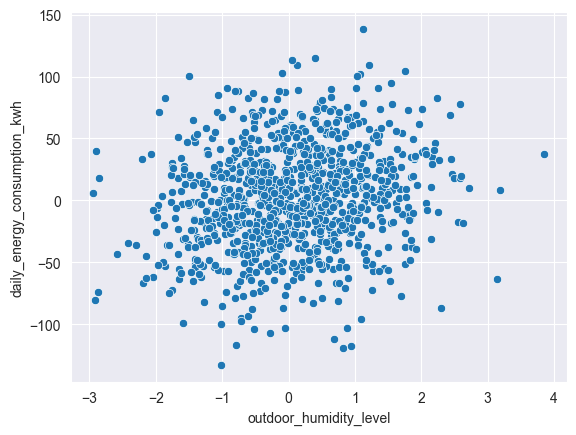

In [18]:
sns.scatterplot(x=df_reg['outdoor_humidity_level'],y=df_reg['daily_energy_consumption_kwh'])
plt.show()

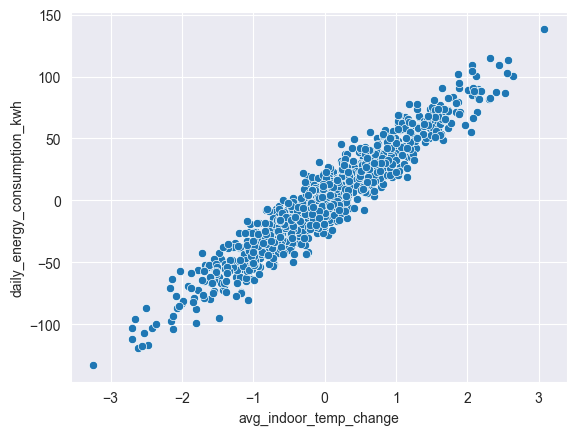

In [19]:
sns.scatterplot(x=df_reg['avg_indoor_temp_change'],y=df_reg['daily_energy_consumption_kwh'])
plt.show()

In [20]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [21]:
X=df_reg.drop('daily_energy_consumption_kwh',axis=1)
y=df_reg['daily_energy_consumption_kwh']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.neighbors import KNeighborsRegressor

In [25]:
regressor=KNeighborsRegressor(n_neighbors=5,algorithm='auto')
regressor.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred=regressor.predict(X_test_scaled)

In [27]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [28]:
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))

r2 score:  0.9152685146562609
mean absolute error:  9.42143518926242
mean squared error:  140.40201685069158


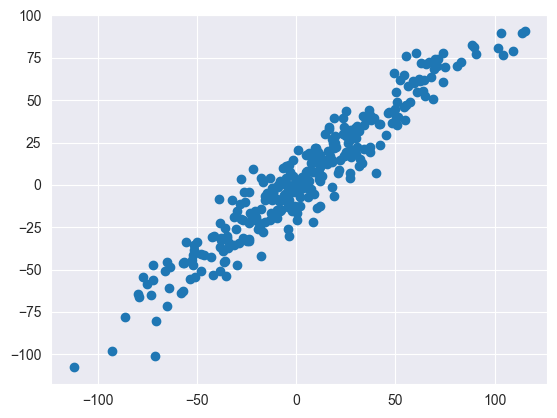

In [29]:
plt.scatter(y_test,y_pred)
plt.show()

In [30]:
regressor=KNeighborsRegressor(n_neighbors=7,algorithm='auto')
regressor.fit(X_train_scaled,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


r2 score:  0.9164863388635838
mean absolute error:  9.331428506491209
mean squared error:  138.3840541750219


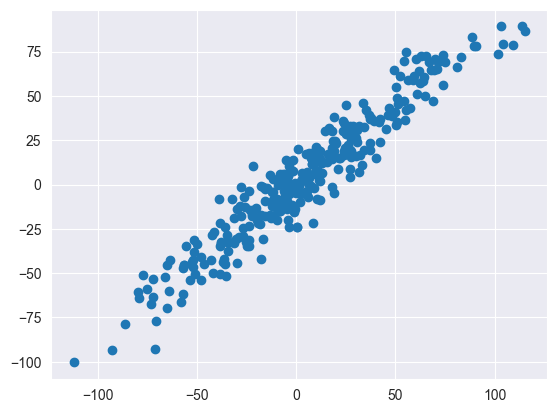

In [31]:
y_pred=regressor.predict(X_test_scaled)
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()

In [32]:
#now use another k values

In [33]:
regressor=KNeighborsRegressor(n_neighbors=25,algorithm='auto') # if you exaggerate k values, your metrics will decrease
regressor.fit(X_train_scaled,y_train)

,n_neighbors,25
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


r2 score:  0.9118719343331324
mean absolute error:  9.42127621485675
mean squared error:  146.0302284396658


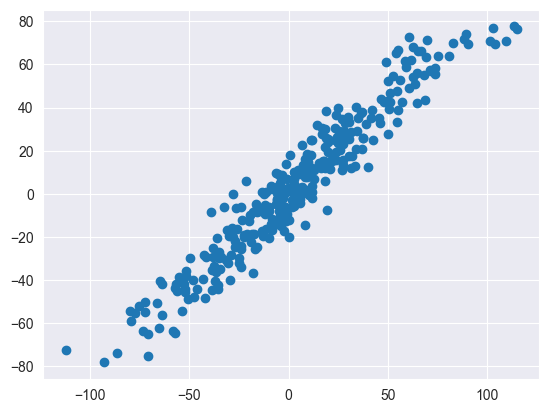

In [34]:
y_pred=regressor.predict(X_test_scaled)
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()